In [ ]:
!pip install transformers==3.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 3.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.0/769.0 kB 20.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 36.5 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)


In [ ]:
!pip list | grep torch


pytorch-ignite                        0.5.2
pytorch-lightning                     2.5.2
torch                                 2.6.0+cu124
torchao                               0.10.0
torchaudio                            2.6.0+cu124
torchdata                             0.11.0
torchinfo                             1.8.0
torchmetrics                          1.7.3
torchsummary                          1.5.1
torchtune                             0.6.1
torchvision                           0.21.0+cu124


In [ ]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


CUDA Available: True
GPU Name: Tesla T4


In [ ]:
!nvidia-smi


Wed Sep 17 15:37:39 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import pandas as pd
from sklearn.utils import resample

# Load the dataset
df = pd.read_csv('/kaggle/input/overall-column-dataset-updated-msc/overall updated upsampled_data.csv')  # Replace with your dataset's file name

# Map scores to labels
def map_scores(score):
    if score in [4, 5]:
        return 2  # Positive
    elif score in [1, 2]:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral

df['Overall_Label'] = df['Overall'].apply(map_scores)  # Replace 'Your_Score_Column' with the actual column name

# Separate the dataset by label
df_0 = df[df['Overall_Label'] == 0]
df_1 = df[df['Overall_Label'] == 1]
df_2 = df[df['Overall_Label'] == 2]

# Perform upsampling
target_size = 3688  # Target size for each label

df_0_upsampled = resample(df_0, replace=True, n_samples=target_size, random_state=42)
df_1_upsampled = resample(df_1, replace=True, n_samples=target_size, random_state=42)
df_2_upsampled = resample(df_2, replace=True, n_samples=target_size, random_state=42)

# Combine the upsampled dataframes
df_balanced = pd.concat([df_0_upsampled, df_1_upsampled, df_2_upsampled])

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the balanced dataset to the working directory
df_balanced.to_csv('balanced_dataset.csv', index=False)

print(f"Balanced dataset saved as 'balanced_dataset.csv' in the working directory.")


Balanced dataset saved as 'balanced_dataset.csv' in the working directory.


In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import seaborn as sns
import transformers
import json
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaModel, RobertaTokenizer
import logging
logging.basicConfig(level=logging.ERROR)

from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'

In [ ]:
import pandas as pd

dataset_path = "/kaggle/working/balanced_dataset.csv"


df = pd.read_csv(dataset_path)
df.head()


,Combined,Overall,Overall_Label
0,"Name: Md Fazla Rabbi, Job_Title: Senior Softwa...",4,2
1,"Name: Fatima Tasnim, Job_Title: Software Engin...",4,2
2,"Name: Rajesh Debnath, Job_Title: Software Engi...",5,2
3,"Name: Foysol Ahmed Shuvo, Job_Title: Full stac...",3,1
4,"Name: Majbah Uddin, Job_Title: Software Engine...",5,2


In [ ]:
# Create the labels based on score
def map_labels(score):
    if score == 1 or score == 2:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral
    elif score == 4 or score == 5:
        return 2  # Positive

# Apply the mapping function to the 'Skills' column
df['Overall_Label'] = df['Overall'].apply(map_labels)

print("Mapped Overall_Label:")
print(df['Overall_Label'].value_counts())

print(df.head())

df.to_csv('/kaggle/working/Overall_Label.csv', index=False)


Mapped Overall_Label:
Overall_Label
2    3688
1    3688
0    3688
Name: count, dtype: int64
                                            Combined  Overall  Overall_Label
0  Name: Md Fazla Rabbi, Job_Title: Senior Softwa...        4              2
1  Name: Fatima Tasnim, Job_Title: Software Engin...        4              2
2  Name: Rajesh Debnath, Job_Title: Software Engi...        5              2
3  Name: Foysol Ahmed Shuvo, Job_Title: Full stac...        3              1
4  Name: Majbah Uddin, Job_Title: Software Engine...        5              2


In [ ]:


from transformers import RobertaTokenizer
import pandas as pd
from sklearn.model_selection import train_test_split
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')


# Load the dataset
df = pd.read_csv("/kaggle/working/Overall_Label.csv")

# Function to tokenize the text using the tokenizer
def tokenize_function(text):
    return tokenizer(
        text,
        padding='max_length',   # pad to max length
        truncation=True,        # truncate if too long
        max_length=256,         # maximum length
        return_tensors='pt'     # return PyTorch tensors
    )

# Apply tokenization to the 'Combined' column
df['tokenized'] = df['Combined'].apply(lambda x: tokenize_function(x))

# Display the first few tokenized outputs and original labels
print(df['tokenized'].head())
print(df[['Combined', 'Overall_Label']].head())


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

0    [input_ids, attention_mask]
1    [input_ids, attention_mask]
2    [input_ids, attention_mask]
3    [input_ids, attention_mask]
4    [input_ids, attention_mask]
Name: tokenized, dtype: object
                                            Combined  Overall_Label
0  Name: Md Fazla Rabbi, Job_Title: Senior Softwa...              2
1  Name: Fatima Tasnim, Job_Title: Software Engin...              2
2  Name: Rajesh Debnath, Job_Title: Software Engi...              2
3  Name: Foysol Ahmed Shuvo, Job_Title: Full stac...              1
4  Name: Majbah Uddin, Job_Title: Software Engine...              2


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/working/Overall_Label.csv")  # This is your labeled data file


# Split the data into training (80%), validation (10%), and test (10%) sets
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

# Check the shape of the split data
print(f"Training Data Shape: {train_data.shape}")
print(f"Validation Data Shape: {val_data.shape}")
print(f"Test Data Shape: {test_data.shape}")

output_dir = "/kaggle/working/"

train_data.to_csv(f"{output_dir}train_data.csv", index=False)
val_data.to_csv(f"{output_dir}val_data.csv", index=False)
test_data.to_csv(f"{output_dir}test_data.csv", index=False)


print("train_data.csv")
print("val_data.csv")
print("test_data.csv")


Training Data Shape: (8851, 3)
Validation Data Shape: (1106, 3)
Test Data Shape: (1107, 3)
train_data.csv
val_data.csv
test_data.csv


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer



# Define the custom PyTorch Dataset
class SkillsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get the combined text and label for a specific index
        text = str(self.data.iloc[idx]['Combined'])
        label = self.data.iloc[idx]['Overall_Label']

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
            return_token_type_ids=True
        )

        # Extract the tensors from the encoding dictionary and squeeze the batch dimension
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        token_type_ids = encoding['token_type_ids'].squeeze(0)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'token_type_ids': token_type_ids,
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Create datasets
train_dataset = SkillsDataset(train_data, tokenizer)
val_dataset = SkillsDataset(val_data, tokenizer)

# Create dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Check a batch from the train DataLoader
for batch in train_dataloader:
    print(f"Input IDs: {batch['input_ids']}")
    print(f"Attention Mask: {batch['attention_mask']}")
    print(f"Token Type IDs: {batch['token_type_ids']}")
    print(f"Labels: {batch['labels']}")
    break  # Just to check one batch only


Input IDs: tensor([[    0, 31723,    35,  ...,    43,    23,     2],
        [    0, 31723,    35,  ..., 20404,  1437,     2],
        [    0, 31723,    35,  ...,     4,   612,     2],
        ...,
        [    0, 31723,    35,  ...,   336,   111,     2],
        [    0, 31723,    35,  ..., 50118, 50118,     2],
        [    0, 31723,    35,  ...,  3546,   401,     2]])
Attention Mask: tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]])
Token Type IDs: tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
Labels: tensor([2, 0, 0, 2, 1, 1, 0, 0, 2, 1, 2, 0, 1, 1, 0, 2])


In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import RobertaForSequenceClassification

# Define the RoBERTa-based model
class RobertaClass(nn.Module):
    def __init__(self, num_labels=3):
        super(RobertaClass, self).__init__()

        self.roberta = RobertaForSequenceClassification.from_pretrained(
            "roberta-base",   # or "roberta-large"
            num_labels=num_labels,
            ignore_mismatched_sizes=True  # Fixes classifier size mismatch if needed
        )

    def forward(self, input_ids, attention_mask):
        # Forward pass through RoBERTa
        output = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        return output.logits

# Initialize the model
model = RobertaClass(num_labels=3)  # Negative (0), Neutral (1), Positive (2)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# Print model summary
print(model)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaClass(
  (roberta): RobertaForSequenceClassification(
    (roberta): RobertaModel(
      (embeddings): RobertaEmbeddings(
        (word_embeddings): Embedding(50265, 768, padding_idx=1)
        (position_embeddings): Embedding(514, 768, padding_idx=1)
        (token_type_embeddings): Embedding(1, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): RobertaEncoder(
        (layer): ModuleList(
          (0-11): 12 x RobertaLayer(
            (attention): RobertaAttention(
              (self): RobertaSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): RobertaSelfOutput(
                (den

In [ ]:
!pip install peft --quiet
!pip install accelerate --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 4.1 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 11.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 23.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 12.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 57.9 MB/s eta 0:00:0000:0100:01


In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, RandomSampler, SequentialSampler
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, get_linear_schedule_with_warmup
import torch.nn as nn
from torch.optim import AdamW   # ✅ Correct import
from sklearn.model_selection import train_test_split

# --------------------------
# Custom Dataset
# --------------------------
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = self.texts[item]
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# --------------------------
# Load data (example assumes df exists)
# --------------------------
# df must have 'Combined' and 'Overall_Label' columns
texts = df['Combined'].tolist()
labels = df['Overall_Label'].tolist()

# Split into train and validation
train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# --------------------------
# Tokenizer & Dataset
# --------------------------
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

train_dataset = TextDataset(train_texts, train_labels, tokenizer, max_len=256)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, max_len=256)

train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=8)
val_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=8)

# --------------------------
# Model
# --------------------------
model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base', num_labels=3, output_attentions=False, output_hidden_states=False
)

# Freeze all layers except classifier
for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

# Move model to GPU(s)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
model.to(device)

# --------------------------
# Optimizer & Scheduler
# --------------------------
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5, weight_decay=0.01)

total_steps = len(train_dataloader) * 19
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),  # 10% warmup
    num_training_steps=total_steps
)

criterion = nn.CrossEntropyLoss()

# --------------------------
# Training & Evaluation
# --------------------------
def train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, scheduler, epochs=18):
    best_val_loss = float('inf')
    patience = 3
    patience_counter = 0

    for epoch in range(epochs):
        # Gradual unfreezing
        if epoch == 5:
            for name, param in model.named_parameters():
                if "encoder.layer.11" in name:
                    param.requires_grad = True
        if epoch == 10:
            for name, param in model.named_parameters():
                if "encoder.layer.10" in name:
                    param.requires_grad = True
        if epoch == 15:
            for name, param in model.named_parameters():
                if "encoder.layer.9" in name:
                    param.requires_grad = True

        # Training loop
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch in train_dataloader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            _, predicted = torch.max(logits, dim=1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = running_loss / len(train_dataloader)
        train_accuracy = correct_train / total_train

        # Validation loop
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
                loss = criterion(logits, labels)
                running_val_loss += loss.item()
                _, predicted = torch.max(logits, dim=1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = running_val_loss / len(val_dataloader)
        val_accuracy = correct_val / total_val

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
        print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

# --------------------------
# Start training
# --------------------------
train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, scheduler, epochs=18)


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using 2 GPUs
Epoch 1/18
Training Loss: 1.0920, Training Accuracy: 0.3741
Validation Loss: 1.0797, Validation Accuracy: 0.3502
Epoch 2/18
Training Loss: 1.0497, Training Accuracy: 0.5694
Validation Loss: 1.0196, Validation Accuracy: 0.7469
Epoch 3/18
Training Loss: 0.9725, Training Accuracy: 0.6804
Validation Loss: 0.9348, Validation Accuracy: 0.8025
Epoch 4/18
Training Loss: 0.8891, Training Accuracy: 0.7300
Validation Loss: 0.8647, Validation Accuracy: 0.6421
Epoch 5/18
Training Loss: 0.8158, Training Accuracy: 0.7643
Validation Loss: 0.7877, Validation Accuracy: 0.8156
Epoch 6/18
Training Loss: 0.7481, Training Accuracy: 0.7793
Validation Loss: 0.7287, Validation Accuracy: 0.7822
Epoch 7/18
Training Loss: 0.6962, Training Accuracy: 0.7962
Validation Loss: 0.6691, Validation Accuracy: 0.8251
Epoch 8/18
Training Loss: 0.6495, Training Accuracy: 0.8099
Validation Loss: 0.6309, Validation Accuracy: 0.8296
Epoch 9/18
Training Loss: 0.6130, Training Accuracy: 0.8216
Validation Loss: 0.5908

In [ ]:
# Saving the trained model and tokenizer
def save_model_and_tokenizer(model, tokenizer, model_path='lastbert_model.pth', tokenizer_path='lastbert_tokenizer'):
    # Save the model's state_dict
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


    tokenizer.save_pretrained(tokenizer_path)
    print(f"Tokenizer saved to {tokenizer_path}")


save_model_and_tokenizer(model, tokenizer)

Model saved to lastbert_model.pth
Tokenizer saved to lastbert_tokenizer


In [ ]:
import torch
from sklearn.metrics import classification_report, hamming_loss
import numpy as np


def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # ✅ Extract logits from SequenceClassifierOutput

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Store probabilities
            probs = torch.softmax(logits, dim=1)
            all_probs.extend(probs.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Check the number of unique labels in the predicted labels
    unique_labels = np.unique(all_labels)
    print(f"Unique Labels: {unique_labels}")

    # Set the correct number of classes and target names
    num_classes = len(unique_labels)
    target_names = [f"Class {i}" for i in unique_labels]

    # Classification Report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    # Hamming Loss
    hamming = hamming_loss(all_labels, all_preds)
    print(f"Hamming Loss: {hamming:.4f}")


# ✅ Run evaluation
evaluate_model(model, val_dataloader, device)


Unique Labels: [0 1 2]
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.99      0.90      0.94       735
     Class 1       0.82      0.72      0.77       752
     Class 2       0.76      0.93      0.84       726

    accuracy                           0.85      2213
   macro avg       0.86      0.85      0.85      2213
weighted avg       0.86      0.85      0.85      2213

Hamming Loss: 0.1509


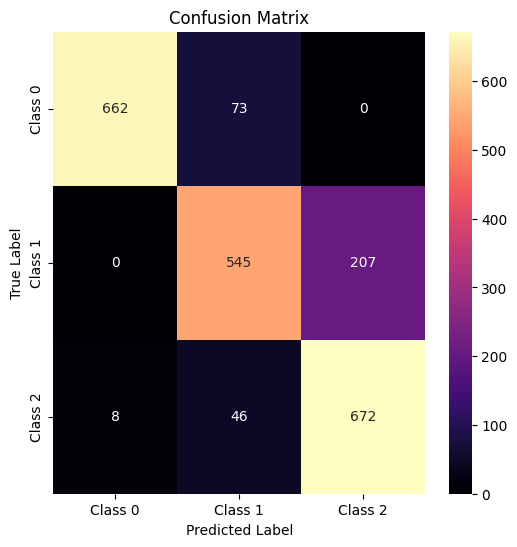

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_model(model, val_dataloader, device, class_names=None, cmap="Blues"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits   # ✅ fix: use .logits

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot
    plot_confusion_matrix(cm, class_names, cmap)


def plot_confusion_matrix(cm, class_names=None, cmap="Blues"):
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, cbar=True,
                xticklabels=class_names if class_names else np.unique(range(cm.shape[0])),
                yticklabels=class_names if class_names else np.unique(range(cm.shape[0])))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


# Example usage:
class_names = ["Class 0", "Class 1", "Class 2"]  # Change based on your dataset
evaluate_model(model, val_dataloader, device, class_names, cmap="magma")  # 🎨 try "Greens", "Purples", "coolwarm"


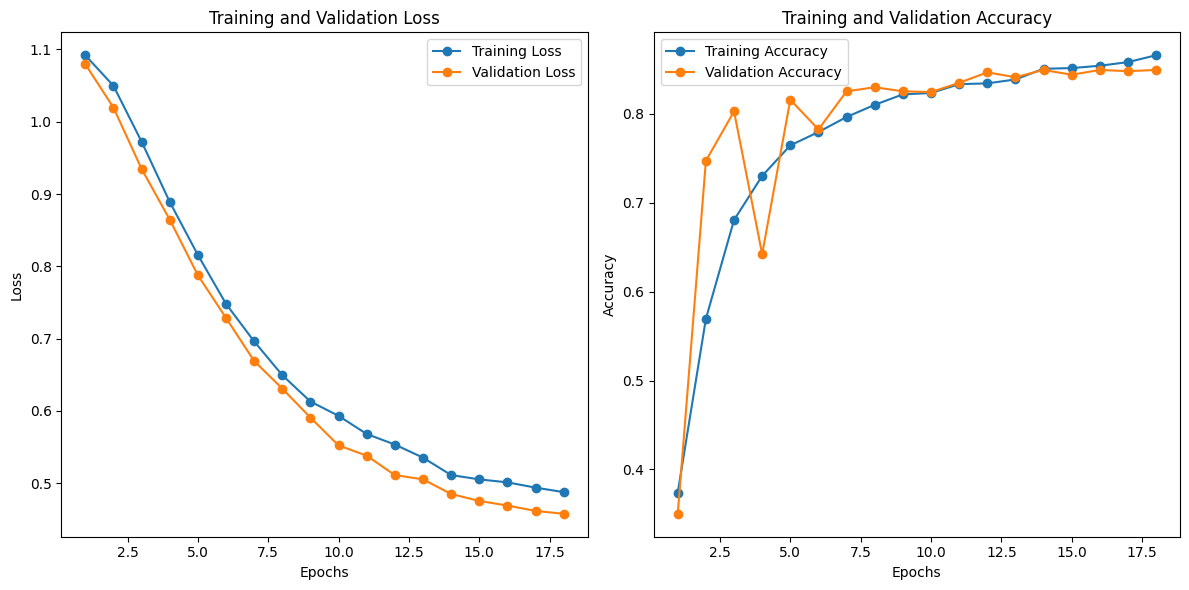

In [ ]:
import matplotlib.pyplot as plt

# Data from the training log
epochs = list(range(1, 21))
# Data
epochs = list(range(1, 19))

training_loss = [1.0920, 1.0497, 0.9725, 0.8891, 0.8158, 0.7481, 0.6962, 0.6495,
              0.6130, 0.5932, 0.5681, 0.5535, 0.5354, 0.5113, 0.5053, 0.5012,
              0.4939, 0.4877]

validation_loss = [1.0797, 1.0196, 0.9348, 0.8647, 0.7877, 0.7287, 0.6691, 0.6309,
            0.5908, 0.5523, 0.5381, 0.5112, 0.5054, 0.4851, 0.4755, 0.4691,
            0.4617, 0.4577]

training_accuracy = [0.3741, 0.5694, 0.6804, 0.7300, 0.7643, 0.7793, 0.7962, 0.8099,
             0.8216, 0.8232, 0.8331, 0.8340, 0.8384, 0.8504, 0.8512, 0.8538,
             0.8579, 0.8656]

validation_accuracy = [0.3502, 0.7469, 0.8025, 0.6421, 0.8156, 0.7822, 0.8251, 0.8296,
           0.8251, 0.8242, 0.8346, 0.8464, 0.8409, 0.8491, 0.8437, 0.8491,
           0.8477, 0.8491]


# Plotting the training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, training_loss, label="Training Loss", marker='o')
plt.plot(epochs, validation_loss, label="Validation Loss", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(False)

# Plotting the training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, training_accuracy, label="Training Accuracy", marker='o')
plt.plot(epochs, validation_accuracy, label="Validation Accuracy", marker='o')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(False)

plt.tight_layout()
plt.show()
